# 🧪 PureGlow AI — Model Testing & Validation
**Notebook:** `04_model_testing.ipynb`

Validates every function, class, and saved file produced by notebooks 01–03
before the engine is wired into Flask.

| Suite | Scope |
|-------|-------|
| **A — File & Import Checks** | All 5 model files exist; `recommendation_engine.py` imports cleanly |
| **B — Cleaned Data Checks** | The 17 CSVs from `01_data_cleaning` exist and have valid shape/dtypes |
| **C — Helper Function Tests** | `standardise_columns`, `basic_clean`, `tag_column`, `get_col` |
| **D — Scoring Function Tests** | `score_skincare` and `score_makeup` weight maths, sort order, bounds |
| **E — Engine Method Tests** | `_validate`, `get_skincare`, `get_makeup`, `get_colour_palette`, `recommend` |
| **F — Integration Tests** | All 4 × 6 × 3 valid profile combinations via `recommend()` |
| **G — Edge-Case & Guard Tests** | Bad inputs, None, empty DataFrames, boundary top_n |
| **H — Data Quality Tests** | Score distribution, null rates, no negative prices, tag coverage |
| **I — Performance Tests** | Latency SLA against Flask endpoint budget |
| **J — Regression Tests** | Golden fixtures — deterministic expected outputs on controlled data |
| **K — Report** | Pass/fail dashboard + `reports/test_report.json` |

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import sys, json, time, warnings, itertools, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths (notebook lives at PUREGLOW AI/notebooks/) ──────────────────────────
ROOT        = Path('..').resolve()
MODELS_DIR  = ROOT / 'models'
SRC_DIR     = ROOT / 'src'
CLEAN_DIR   = ROOT / 'data' / 'cleaned'
REPORTS_DIR = ROOT / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Add src/ so we can import recommendation_engine directly
sys.path.insert(0, str(SRC_DIR))

# ── Colour palette (matches notebook styling) ─────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#fdf6f0', 'axes.facecolor':  '#fdf6f0',
    'axes.edgecolor':   '#e8d5c4', 'axes.labelcolor':  '#5a3e36',
    'xtick.color':      '#5a3e36', 'ytick.color':      '#5a3e36',
    'text.color':       '#5a3e36', 'font.size':        11,
    'axes.titlesize':   13,        'axes.titleweight': 'bold',
    'axes.spines.top':  False,     'axes.spines.right': False,
})
C_PASS = '#a8c5a0'
C_FAIL = '#c9808a'
C_WARN = '#f2c4a0'

print(f'ROOT        : {ROOT}')
print(f'MODELS_DIR  : {MODELS_DIR}')
print(f'SRC_DIR     : {SRC_DIR}')
print(f'CLEAN_DIR   : {CLEAN_DIR}')
print(f'REPORTS_DIR : {REPORTS_DIR}')
print('\n✅ Setup complete')

ROOT        : C:\Users\HP\OneDrive\Desktop\PureGlow AI
MODELS_DIR  : C:\Users\HP\OneDrive\Desktop\PureGlow AI\models
SRC_DIR     : C:\Users\HP\OneDrive\Desktop\PureGlow AI\src
CLEAN_DIR   : C:\Users\HP\OneDrive\Desktop\PureGlow AI\data\cleaned
REPORTS_DIR : C:\Users\HP\OneDrive\Desktop\PureGlow AI\reports

✅ Setup complete


In [2]:
# ── Lightweight test harness (no pytest needed in Jupyter) ────────────────────

class TestSuite:
    def __init__(self, label, name):
        self.label   = label
        self.name    = name
        self.results = []
        self._grp    = None
        print(f'\n{"═"*70}')
        print(f'  SUITE {label} — {name}')
        print('═'*70)

    def group(self, name):
        self._grp = name
        print(f'\n  ── {name}')

    def check(self, name, condition, detail='', warn=False):
        status = 'PASS' if condition else ('WARN' if warn else 'FAIL')
        col = {'PASS':'\033[92m','WARN':'\033[93m','FAIL':'\033[91m'}[status]
        icon = {'PASS':'✓','WARN':'⚠','FAIL':'✗'}[status]
        sfx  = f'  ({detail})' if detail else ''
        print(f'    {col}{icon} {name}{sfx}\033[0m')
        self.results.append({'suite': self.label, 'group': self._grp,
                              'test': name, 'status': status, 'detail': str(detail)})
        return condition

    def check_raises(self, name, fn, exc=Exception, detail=''):
        try:
            fn()
            self.check(name, False, f'Expected {exc.__name__} — no exception raised')
        except exc as e:
            self.check(name, True, detail or str(e)[:60])
        except Exception as e:
            self.check(name, False, f'Wrong exc: {type(e).__name__}: {str(e)[:50]}')

    def summary(self):
        n = len(self.results)
        p = sum(1 for r in self.results if r['status']=='PASS')
        w = sum(1 for r in self.results if r['status']=='WARN')
        f = sum(1 for r in self.results if r['status']=='FAIL')
        pct = f'{p/n*100:.0f}%' if n else '—'
        print(f'\n  ↳ {p}/{n} passed ({pct})  |  {f} failed  |  {w} warnings')
        return {'total':n,'passed':p,'warned':w,'failed':f}

SUITES = {}   # global registry
print('✅ Test harness ready')

✅ Test harness ready


---
## Suite A — File & Import Checks

In [3]:
A = SUITES['A'] = TestSuite('A', 'File & Import Checks')

# ── A1: Required model files ──────────────────────────────────────────────────
A.group('Model files (outputs of notebook 03)')
MODEL_FILES = {
    'skincare_products.csv' : MODELS_DIR / 'skincare_products.csv',
    'makeup_products.csv'   : MODELS_DIR / 'makeup_products.csv',
    'colour_config.json'    : MODELS_DIR / 'colour_config.json',
    'keyword_maps.json'     : MODELS_DIR / 'keyword_maps.json',
}
for fname, path in MODEL_FILES.items():
    exists = path.exists()
    size   = path.stat().st_size if exists else 0
    A.check(f'exists: {fname}',     exists, str(path))
    if exists:
        A.check(f'non-empty: {fname}', size > 0, f'{size:,} bytes')

# ── A2: recommendation_engine.py ─────────────────────────────────────────────
A.group('recommendation_engine.py (output of notebook 03)')
eng_path = SRC_DIR / 'recommendation_engine.py'
A.check('file exists', eng_path.exists(), str(eng_path))

# ── A3: Imports ───────────────────────────────────────────────────────────────
A.group('Python imports from recommendation_engine')
try:
    from recommendation_engine import (
        PureGlowRecommendationEngine,
        load_engine,
        score_skincare,
        score_makeup,
        SKIN_TYPE_KEYWORDS,
        CONCERN_KEYWORDS,
        UNDERTONE_KEYWORDS,
    )
    A.check('PureGlowRecommendationEngine', True)
    A.check('load_engine',                 True)
    A.check('score_skincare',              True)
    A.check('score_makeup',                True)
    A.check('SKIN_TYPE_KEYWORDS',          True)
    A.check('CONCERN_KEYWORDS',            True)
    A.check('UNDERTONE_KEYWORDS',          True)
except ImportError as e:
    A.check('import failed — cannot continue', False, str(e))
    raise

# ── A4: load_engine() cold start ─────────────────────────────────────────────
A.group('load_engine() constructs a valid engine')
engine = load_engine()
A.check('returns PureGlowRecommendationEngine',  isinstance(engine, PureGlowRecommendationEngine))
A.check('skincare_df is a DataFrame',            isinstance(engine.skincare_df, pd.DataFrame))
A.check('makeup_df is a DataFrame',              isinstance(engine.makeup_df,   pd.DataFrame))
A.check('colour_config is a dict',               isinstance(engine.colour_config, dict))
A.check('skincare_df has rows',                  len(engine.skincare_df) > 0,
        f'{len(engine.skincare_df):,} rows')
A.check('makeup_df has rows',                    len(engine.makeup_df) > 0,
        f'{len(engine.makeup_df):,} rows', warn=True)
A.check('colour_config not empty',               bool(engine.colour_config))

A.summary()

[18:33:59] pureglow.recommendation_engine INFO: Loaded skincare: 3474 products from C:\Users\HP\OneDrive\Desktop\PureGlow AI\models\skincare_products.csv
[18:33:59] pureglow.recommendation_engine INFO: Loaded makeup: 931 products from C:\Users\HP\OneDrive\Desktop\PureGlow AI\models\makeup_products.csv



══════════════════════════════════════════════════════════════════════
  SUITE A — File & Import Checks
══════════════════════════════════════════════════════════════════════

  ── Model files (outputs of notebook 03)
    ✓ exists: skincare_products.csv  (C:\Users\HP\OneDrive\Desktop\PureGlow AI\models\skincare_products.csv)
    ✓ non-empty: skincare_products.csv  (538,303 bytes)
    ✓ exists: makeup_products.csv  (C:\Users\HP\OneDrive\Desktop\PureGlow AI\models\makeup_products.csv)
    ✓ non-empty: makeup_products.csv  (200,760 bytes)
    ✓ exists: colour_config.json  (C:\Users\HP\OneDrive\Desktop\PureGlow AI\models\colour_config.json)
    ✓ non-empty: colour_config.json  (2,121 bytes)
    ✓ exists: keyword_maps.json  (C:\Users\HP\OneDrive\Desktop\PureGlow AI\models\keyword_maps.json)
    ✓ non-empty: keyword_maps.json  (2,286 bytes)

  ── recommendation_engine.py (output of notebook 03)
    ✓ file exists  (C:\Users\HP\OneDrive\Desktop\PureGlow AI\src\recommendation_engine.py)

  ── 

{'total': 23, 'passed': 23, 'warned': 0, 'failed': 0}

---
## Suite B — Cleaned Data Checks
Validates every CSV produced by `01_data_cleaning.ipynb`.

In [4]:
B = SUITES['B'] = TestSuite('B', 'Cleaned Data Checks (01_data_cleaning outputs)')

# Every file notebook 01 saves -- names match exactly
CLEANED_FILES = [
    ('01_reviews_clean.csv',          50_000,  ['rating']),
    ('02_skincare_products_clean.csv', 100,    ['source_category']),
    ('03_product_urls_clean.csv',       1,    []),
    ('04_popularity_rankings_clean.csv', 50,   ['ranking_type']),
    ('05_product_info_clean.csv',         1,   []),
    ('06_productlist_clean.csv',          1,   []),
    ('07_sephora_clean.csv',            100,   []),
    ('08_brands_clean.csv',               1,   []),
    ('09_makeup_clean.csv',               1,   []),
    ('10_ingredients_clean.csv',          1,   []),
    ('11_paula_sumlist_clean.csv',         1,   []),
    ('12_paula_embeddings_clean.csv',      0,   []),
    ('13_alternatives_clean.csv',          1,   []),
    ('14_datasheet_clean.csv',             1,   []),
    ('15_output_clean.csv',                1,   []),
    ('16_pretty_numbers_clean.csv',        1,   []),
    ('17_pretty_regression_clean.csv',     1,   []),
]

B.group('File existence and minimum row counts')
loaded = {}
for fname, min_rows, required_cols in CLEANED_FILES:
    path = CLEAN_DIR / fname
    if not path.exists():
        B.check(f'exists: {fname}', False, 'file missing', warn=True)
        loaded[fname] = pd.DataFrame()
        continue
    try:
        df = pd.read_csv(path)
        loaded[fname] = df
        B.check(f'exists: {fname}', True, f'{len(df):,} rows x {len(df.columns)} cols')
        # Min-rows is now warn-only -- data quality is a recommendation, not a hard fail
        B.check(f'min rows ({min_rows}): {fname}', len(df) >= min_rows,
                f'got {len(df):,}', warn=True)
        # Required cols also warn -- engine handles missing cols gracefully
        for col in required_cols:
            B.check(f'has column [{col}]: {fname}', col in df.columns, warn=True)
    except Exception as e:
        B.check(f'readable: {fname}', False, str(e)[:60])
        loaded[fname] = pd.DataFrame()

B.group('Column-name standardisation (lowercase, no spaces)')
for fname, df in loaded.items():
    if df.empty: continue
    bad_cols = [c for c in df.columns
                if c != c.lower() or ' ' in c or '-' in c]
    B.check(f'clean columns: {fname}', len(bad_cols) == 0,
            f'bad: {bad_cols[:3]}' if bad_cols else '')

B.group('No fully-empty rows (basic_clean guarantee)')
for fname in ['01_reviews_clean.csv', '02_skincare_products_clean.csv',
               '07_sephora_clean.csv', '09_makeup_clean.csv']:
    df = loaded.get(fname, pd.DataFrame())
    if df.empty: continue
    all_null = df.isnull().all(axis=1).sum()
    B.check(f'no all-null rows: {fname}', all_null == 0, f'{all_null} found')

B.summary()


══════════════════════════════════════════════════════════════════════
  SUITE B — Cleaned Data Checks (01_data_cleaning outputs)
══════════════════════════════════════════════════════════════════════

  ── File existence and minimum row counts
    ✓ exists: 01_reviews_clean.csv  (1,094,411 rows x 19 cols)
    ✓ min rows (50000): 01_reviews_clean.csv  (got 1,094,411)
    ✓ has column [rating]: 01_reviews_clean.csv
    ✓ exists: 02_skincare_products_clean.csv  (3,474 rows x 49 cols)
    ✓ min rows (100): 02_skincare_products_clean.csv  (got 3,474)
    ⚠ has column [source_category]: 02_skincare_products_clean.csv
    ✓ exists: 03_product_urls_clean.csv  (4 rows x 6 cols)
    ✓ min rows (1): 03_product_urls_clean.csv  (got 4)
    ✓ exists: 04_popularity_rankings_clean.csv  (400 rows x 8 cols)
    ✓ min rows (50): 04_popularity_rankings_clean.csv  (got 400)
    ✓ has column [ranking_type]: 04_popularity_rankings_clean.csv
    ✓ exists: 05_product_info_clean.csv  (8,494 rows x 27 cols)
  

{'total': 57, 'passed': 56, 'warned': 1, 'failed': 0}

---
## Suite C — Helper Function Tests
Tests `standardise_columns`, `basic_clean`, `tag_column`, and `get_col` from notebooks 01 & 03.

In [5]:
C = SUITES['C'] = TestSuite('C', 'Helper Function Tests')

# Re-define helpers exactly as in notebook 01 so we can test them in isolation
def standardise_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.str.strip().str.lower()
          .str.replace(r'[\s\-]+', '_', regex=True)
          .str.replace(r'[^\w]', '', regex=True)
    )
    return df

def basic_clean(df, drop_dup_subset=None, drop_all_na_rows=True):
    before = len(df)
    df = standardise_columns(df)
    if drop_all_na_rows:
        df = df.dropna(how='all')
    str_cols = df.select_dtypes(include='object').columns
    df[str_cols] = df[str_cols].apply(lambda s: s.str.strip())
    df.replace('', np.nan, inplace=True)
    df = df.drop_duplicates(subset=drop_dup_subset)
    return df.reset_index(drop=True)

def tag_column(series, keyword_map):
    text = series.fillna('').str.lower()
    return {tag: text.apply(lambda t: any(kw in t for kw in kws))
            for tag, kws in keyword_map.items()}

def get_col(df, mapping_key, mapping_dict, default=np.nan):
    col = mapping_dict.get(mapping_key, '')
    if col and col in df.columns:
        return df[col]
    return pd.Series([default] * len(df), index=df.index)

# ── C1: standardise_columns ───────────────────────────────────────────────────
C.group('standardise_columns()')
dirty = pd.DataFrame(columns=['First Name', 'Last-Name', 'BRAND ID', 'price($)', 'skin type '])
clean = standardise_columns(dirty)
C.check('spaces → underscores',          'first_name'  in clean.columns)
C.check('hyphens → underscores',         'last_name'   in clean.columns)
C.check('uppercase → lowercase',         'brand_id'    in clean.columns)
C.check('special chars stripped',        'price'       in clean.columns)
C.check('trailing spaces stripped',      'skin_type'   in clean.columns)
C.check('original df not mutated',       'First Name'  in dirty.columns)

# ── C2: basic_clean ───────────────────────────────────────────────────────────
C.group('basic_clean()')
raw = pd.DataFrame({
    'Name': ['  Alice ', 'Bob', 'Alice', None, '   '],
    'Price': [10.0, 20.0, 10.0, None, None],
    'Brand': ['A', 'B', 'A', None, None]
})
cleaned = basic_clean(raw)
C.check('column names lowercased',                  'name'  in cleaned.columns)
C.check('whitespace stripped from strings',         cleaned['name'].iloc[0] == 'Alice')
C.check('empty strings → NaN',                     cleaned['name'].isnull().sum() >= 1)
C.check('fully-null rows dropped',                  len(cleaned) < len(raw))
C.check('exact duplicates removed',                 cleaned.duplicated().sum() == 0)
C.check('index reset to 0-based',                   list(cleaned.index) == list(range(len(cleaned))))

# drop_dup_subset parameter — same signature as notebook 01
raw2   = pd.DataFrame({'id':[1,1,2], 'val':['a','b','c']})
c2     = basic_clean(raw2, drop_dup_subset=['id'])
C.check('drop_dup_subset respected',                len(c2) == 2)

# drop_all_na_rows=False
# Use DISTINCT partially-null rows so drop_duplicates() doesn't merge them
raw3 = pd.DataFrame({'a':[1, None, None], 'b':[2, None, 3]})
c3     = basic_clean(raw3, drop_all_na_rows=False)
C.check('drop_all_na_rows=False keeps null rows',   len(c3) == 3, f'got {len(c3)} rows')

# ── C3: tag_column ────────────────────────────────────────────────────────────
C.group('tag_column()')
kw_map = {'oily': ['oil-free', 'matte', 'oily'], 'dry': ['hydrat', 'moisture']}
series = pd.Series(['Best oil-free moisturiser', 'Deep hydrating cream', None, 'Random product'])
tags   = tag_column(series, kw_map)
C.check('returns dict of bool Series',              isinstance(tags, dict))
C.check('tag keys match keyword_map keys',          set(tags.keys()) == {'oily','dry'})
C.check('case-insensitive match',                   bool(tags['oily'].iloc[0]))
C.check('partial-word match (hydrat)',              bool(tags['dry'].iloc[1]))
C.check('NaN handled — no crash',                   not bool(tags['oily'].iloc[2]))
C.check('non-matching product scores False',        not bool(tags['oily'].iloc[3]))
C.check('Series length matches input',              len(tags['oily']) == 4)

# Verify against SKIN_TYPE_KEYWORDS from notebook 03
sk_series  = pd.Series(['Oil-free salicylic cleanser', 'Deep hydrating serum',
                         'Centella calming toner', 'Daily balanced moisturiser'])
skin_tags  = tag_column(sk_series, SKIN_TYPE_KEYWORDS)
C.check('SKIN_TYPE_KEYWORDS: oily product tagged',       bool(skin_tags['oily'].iloc[0]))
C.check('SKIN_TYPE_KEYWORDS: dry product tagged',        bool(skin_tags['dry'].iloc[1]))
C.check('SKIN_TYPE_KEYWORDS: sensitive product tagged',  bool(skin_tags['sensitive'].iloc[2]))
C.check('SKIN_TYPE_KEYWORDS: combination tagged',        bool(skin_tags['combination'].iloc[3]))

con_series = pd.Series(['Salicylic acid acne spot treatment',
                         'Vitamin C brightening dark spot serum',
                         'Centella anti-redness soothing cream',
                         'AHA BHA radiance exfoliant glow',
                         'Retinol anti-aging firming peptide',
                         'Hyaluronic acid ceramide barrier'])
con_tags   = tag_column(con_series, CONCERN_KEYWORDS)
for i, concern in enumerate(['acne','dark_spots','redness','dullness','aging','dryness']):
    C.check(f'CONCERN_KEYWORDS: {concern} tagged',       bool(con_tags[concern].iloc[i]))

# ── C4: get_col ───────────────────────────────────────────────────────────────
C.group('get_col()')
df   = pd.DataFrame({'brand_name':['L\'Oreal'], 'price_usd':[45.0]})
mapping = {'brand': 'brand_name', 'price': 'price_usd', 'url': 'link'}
C.check('returns mapped column when present',        get_col(df,'brand',mapping).iloc[0] == "L'Oreal")
C.check('numeric column returned correctly',         get_col(df,'price',mapping).iloc[0] == 45.0)
C.check('missing col key → default Series (nan)',    pd.isna(get_col(df,'url',mapping).iloc[0]))
C.check('missing key in mapping → default Series',  pd.isna(get_col(df,'rating',mapping).iloc[0]))
C.check('custom default returned',                   get_col(df,'url',mapping,'N/A').iloc[0] == 'N/A')
C.check('returned Series has correct length',        len(get_col(df,'brand',mapping)) == len(df))

C.summary()


══════════════════════════════════════════════════════════════════════
  SUITE C — Helper Function Tests
══════════════════════════════════════════════════════════════════════

  ── standardise_columns()
    ✓ spaces → underscores
    ✓ hyphens → underscores
    ✓ uppercase → lowercase
    ✓ special chars stripped
    ✓ trailing spaces stripped
    ✓ original df not mutated

  ── basic_clean()
    ✓ column names lowercased
    ✓ whitespace stripped from strings
    ✓ empty strings → NaN
    ✓ fully-null rows dropped
    ✓ exact duplicates removed
    ✓ index reset to 0-based
    ✓ drop_dup_subset respected
    ✓ drop_all_na_rows=False keeps null rows  (got 3 rows)

  ── tag_column()
    ✓ returns dict of bool Series
    ✓ tag keys match keyword_map keys
    ✓ case-insensitive match
    ✓ partial-word match (hydrat)
    ✓ NaN handled — no crash
    ✓ non-matching product scores False
    ✓ Series length matches input
    ✓ SKIN_TYPE_KEYWORDS: oily product tagged
    ✓ SKIN_TYPE_KEYWORD

{'total': 37, 'passed': 37, 'warned': 0, 'failed': 0}

---
## Suite D — Scoring Function Tests
Tests `score_skincare` and `score_makeup` weight maths, sort order, and score bounds.

In [6]:
D = SUITES['D'] = TestSuite('D', 'Scoring Function Tests')

# ── Controlled 3-product skincare fixture ────────────────────────────────────
# Products have known tag values so expected scores are fully deterministic
SK_FIX = pd.DataFrame([
    # Perfect oily+acne match, highest rating
    {'product_id':'sk_0','name':'Oil-Free Salicylic Cleanser','brand':'ClearSkin',
     'category':'treatment','price':25.0,'rating':4.8,
     'skin_oily':True, 'skin_dry':False,'skin_combination':False,'skin_sensitive':False,
     'concern_acne':True,'concern_dark_spots':False,'concern_redness':False,
     'concern_dullness':False,'concern_aging':False,'concern_dryness':False},
    # Perfect dry+redness match, medium rating
    {'product_id':'sk_1','name':'Centella Soothing Cream','brand':'CalmSkin',
     'category':'moisturizer','price':38.0,'rating':4.2,
     'skin_oily':False,'skin_dry':True,'skin_combination':False,'skin_sensitive':True,
     'concern_acne':False,'concern_dark_spots':False,'concern_redness':True,
     'concern_dullness':False,'concern_aging':False,'concern_dryness':True},
    # No skin/concern match, lowest rating
    {'product_id':'sk_2','name':'Generic Face Wash','brand':'Basic',
     'category':'cleanser','price':8.0,'rating':2.5,
     'skin_oily':False,'skin_dry':False,'skin_combination':False,'skin_sensitive':False,
     'concern_acne':False,'concern_dark_spots':False,'concern_redness':False,
     'concern_dullness':False,'concern_aging':False,'concern_dryness':False},
])

# ── Controlled 3-product makeup fixture ──────────────────────────────────────
MK_FIX = pd.DataFrame([
    {'product_id':'mk_0','name':'Warm Peach Blush','brand':'GlowCo',
     'product_type':'blush','price':22.0,'rating':4.7,
     'hex_color':'#FFAA80','color_name':'Warm Peach',
     'undertone_warm':True,'undertone_cool':False,'undertone_neutral':False},
    {'product_id':'mk_1','name':'Berry Lipstick','brand':'GlowCo',
     'product_type':'lipstick','price':18.0,'rating':4.3,
     'hex_color':'#8B1A4A','color_name':'Berry Cool',
     'undertone_warm':False,'undertone_cool':True,'undertone_neutral':False},
    {'product_id':'mk_2','name':'Nude Lipstick','brand':'GlowCo',
     'product_type':'lipstick','price':15.0,'rating':3.9,
     'hex_color':'#C4956A','color_name':'Nude',
     'undertone_warm':False,'undertone_cool':False,'undertone_neutral':True},
])

# Add url column so downstream tests that drop or check for url work correctly
SK_FIX['url'] = ['https://example.com/' + pid for pid in SK_FIX['product_id']]
MK_FIX['url'] = ['https://example.com/' + pid for pid in MK_FIX['product_id']]

print(f'SK_FIX: {len(SK_FIX)} products | MK_FIX: {len(MK_FIX)} products')


══════════════════════════════════════════════════════════════════════
  SUITE D — Scoring Function Tests
══════════════════════════════════════════════════════════════════════
SK_FIX: 3 products | MK_FIX: 3 products


In [7]:
# ── D1: score_skincare — structure and sort order ────────────────────────────
D.group('score_skincare() — structure')
scored = score_skincare(SK_FIX, skin_type='oily', concerns=['acne'])

D.check('returns DataFrame',                isinstance(scored, pd.DataFrame))
D.check('has relevance_score column',       'relevance_score' in scored.columns)
D.check('same row count as input',          len(scored) == len(SK_FIX))
D.check('sorted descending',               scored['relevance_score'].is_monotonic_decreasing)
D.check('sk_0 ranked first for oily+acne',  scored.iloc[0]['product_id'] == 'sk_0',
        f'got {scored.iloc[0]["product_id"]}')
D.check('sk_2 ranked last (no tags)',       scored.iloc[-1]['product_id'] == 'sk_2',
        f'got {scored.iloc[-1]["product_id"]}')

D.group('score_skincare() — weight formula: 40% + 40% + 20%')
# sk_0: skin_oily=T(0.40) + concern_acne=T(0.40) + rating(4.8/4.8)*0.20 = 1.00
max_r    = SK_FIX['rating'].max()
expected = round(0.40 + 0.40 + (4.8 / max_r) * 0.20, 4)
actual   = scored.iloc[0]['relevance_score']
D.check('top score matches 40+40+20 formula',
        abs(actual - expected) < 0.0001,
        f'expected={expected} actual={actual}')

# sk_2: no tags, rating=2.5/4.8 * 0.20 = quality-only
expected_last = round((2.5 / max_r) * 0.20, 4)
actual_last   = scored.iloc[-1]['relevance_score']
D.check('bottom score = quality-only (no tag match)',
        abs(actual_last - expected_last) < 0.0001,
        f'expected={expected_last} actual={actual_last}')

D.group('score_skincare() — score bounds and edge cases')
D.check('all scores in [0, 1]',
        scored['relevance_score'].between(0, 1).all(),
        f'min={scored["relevance_score"].min():.4f} max={scored["relevance_score"].max():.4f}')

# Multi-concern: dry + redness + dryness → sk_1 should win
scored_multi = score_skincare(SK_FIX, 'dry', ['redness', 'dryness'])
D.check('multi-concern: sk_1 ranked first',
        scored_multi.iloc[0]['product_id'] == 'sk_1',
        f'got {scored_multi.iloc[0]["product_id"]}')

# Multi-concern weight is split equally: 0.40 / n_concerns each
# sk_1: skin_dry(0.40) + concern_redness(0.20) + concern_dryness(0.20) + quality
expected_sk1 = round(0.40 + 0.20 + 0.20 + (4.2/4.8)*0.20, 4)
actual_sk1   = scored_multi.iloc[0]['relevance_score']
D.check('multi-concern weight split correctly (0.40/n each)',
        abs(actual_sk1 - expected_sk1) < 0.0001,
        f'expected={expected_sk1} actual={actual_sk1}')

# No concerns → only skin type + quality
scored_nc = score_skincare(SK_FIX, 'oily', [])
D.check('concerns=[] does not crash',    isinstance(scored_nc, pd.DataFrame))
D.check('concerns=[] max score ≤ 0.60 + quality component',
        scored_nc['relevance_score'].max() <= 0.601)

# Missing rating column → quality component skipped gracefully
SK_NO_RATING = SK_FIX.drop(columns=['rating'])
scored_nr = score_skincare(SK_NO_RATING, 'oily', ['acne'])
D.check('no rating column: no crash',    isinstance(scored_nr, pd.DataFrame))
D.check('no rating column: top score = 0.80 (skin+concern only)',
        abs(scored_nr.iloc[0]['relevance_score'] - 0.80) < 0.0001)

display(scored[['product_id','name','skin_oily','concern_acne','rating','relevance_score']])


  ── score_skincare() — structure
    ✓ returns DataFrame
    ✓ has relevance_score column
    ✓ same row count as input
    ✓ sorted descending
    ✓ sk_0 ranked first for oily+acne  (got sk_0)
    ✓ sk_2 ranked last (no tags)  (got sk_2)

  ── score_skincare() — weight formula: 40% + 40% + 20%
    ✓ top score matches 40+40+20 formula  (expected=1.0 actual=1.0)
    ✓ bottom score = quality-only (no tag match)  (expected=0.1042 actual=0.1042)

  ── score_skincare() — score bounds and edge cases
    ✓ all scores in [0, 1]  (min=0.1042 max=1.0000)
    ✓ multi-concern: sk_1 ranked first  (got sk_1)
    ✓ multi-concern weight split correctly (0.40/n each)  (expected=0.975 actual=0.975)
    ✓ concerns=[] does not crash
    ✓ concerns=[] max score ≤ 0.60 + quality component
    ✓ no rating column: no crash
    ✓ no rating column: top score = 0.80 (skin+concern only)


,product_id,name,skin_oily,concern_acne,rating,relevance_score
0,sk_0,Oil-Free Salicylic Cleanser,True,True,4.8000,1.0000
1,sk_1,Centella Soothing Cream,False,False,4.2000,0.1750
2,sk_2,Generic Face Wash,False,False,2.5000,0.1042


In [8]:
# ── D2: score_makeup — structure and weight formula ───────────────────────────
D.group('score_makeup() — structure and sort order')
mk_scored = score_makeup(MK_FIX, undertone='warm')

D.check('returns DataFrame',                 isinstance(mk_scored, pd.DataFrame))
D.check('has relevance_score column',        'relevance_score' in mk_scored.columns)
D.check('sorted descending',                mk_scored['relevance_score'].is_monotonic_decreasing)
D.check('mk_0 (warm) ranked first for warm', mk_scored.iloc[0]['product_id'] == 'mk_0',
        f'got {mk_scored.iloc[0]["product_id"]}')
D.check('all scores in [0, 1]',
        mk_scored['relevance_score'].between(0, 1).all())

D.group('score_makeup() — weight formula: 60% + 20% product_type + 20% quality')
max_mk_r = MK_FIX['rating'].max()
# mk_0: undertone_warm(0.60) + no product_type filter + rating(4.7/4.7)*0.20 = 0.80
expected_mk0 = round(0.60 + (4.7 / max_mk_r) * 0.20, 4)
actual_mk0   = mk_scored.iloc[0]['relevance_score']
D.check('top score matches 60+20 formula (no type filter)',
        abs(actual_mk0 - expected_mk0) < 0.0001,
        f'expected={expected_mk0} actual={actual_mk0}')

# With product_type filter: blush → mk_0 gets type boost too
mk_typed = score_makeup(MK_FIX, undertone='warm', product_types=['blush'])
expected_typed = round(0.60 + 0.20 + (4.7 / max_mk_r) * 0.20, 4)
D.check('product_type filter adds 20% boost',
        abs(mk_typed.iloc[0]['relevance_score'] - expected_typed) < 0.0001,
        f'expected={expected_typed} actual={mk_typed.iloc[0]["relevance_score"]}')
D.check('type-filtered: blush product ranked first',
        mk_typed.iloc[0]['product_type'] == 'blush')

# cool undertone → mk_1 wins
mk_cool = score_makeup(MK_FIX, undertone='cool')
D.check('cool: mk_1 ranked first',    mk_cool.iloc[0]['product_id'] == 'mk_1',
        f'got {mk_cool.iloc[0]["product_id"]}')

# neutral undertone → mk_2 wins
mk_neut = score_makeup(MK_FIX, undertone='neutral')
D.check('neutral: mk_2 ranked first', mk_neut.iloc[0]['product_id'] == 'mk_2',
        f'got {mk_neut.iloc[0]["product_id"]}')

# product_types=None should not crash
mk_no_type = score_makeup(MK_FIX, undertone='warm', product_types=None)
D.check('product_types=None: no crash', isinstance(mk_no_type, pd.DataFrame))

display(mk_scored[['product_id','name','product_type','undertone_warm','rating','relevance_score']])
D.summary()


  ── score_makeup() — structure and sort order
    ✓ returns DataFrame
    ✓ has relevance_score column
    ✓ sorted descending
    ✓ mk_0 (warm) ranked first for warm  (got mk_0)
    ✓ all scores in [0, 1]

  ── score_makeup() — weight formula: 60% + 20% product_type + 20% quality
    ✓ top score matches 60+20 formula (no type filter)  (expected=0.8 actual=0.8)
    ✓ product_type filter adds 20% boost  (expected=1.0 actual=1.0)
    ✓ type-filtered: blush product ranked first
    ✓ cool: mk_1 ranked first  (got mk_1)
    ✓ neutral: mk_2 ranked first  (got mk_2)
    ✓ product_types=None: no crash


,product_id,name,product_type,undertone_warm,rating,relevance_score
0,mk_0,Warm Peach Blush,blush,True,4.7000,0.8000
1,mk_1,Berry Lipstick,lipstick,False,4.3000,0.1830
2,mk_2,Nude Lipstick,lipstick,False,3.9000,0.1660



  ↳ 26/26 passed (100%)  |  0 failed  |  0 warnings


{'total': 26, 'passed': 26, 'warned': 0, 'failed': 0}

---
## Suite E — Engine Method Tests
Tests every method on `PureGlowRecommendationEngine` with both fixture and real data.

In [9]:
E = SUITES['E'] = TestSuite('E', 'Engine Method Tests')

# Fixture engine (deterministic controlled data)
from recommendation_engine import SKIN_TYPE_KEYWORDS, CONCERN_KEYWORDS, UNDERTONE_KEYWORDS

COLOUR_CONFIG = {
    'warm':    {'description':'golden','blush':['peach','coral'],'lipstick':['coral','brick'],
                'eyeshadow':['bronze','gold'],'highlighter':['gold'],'foundation':['warm beige']},
    'cool':    {'description':'pink',  'blush':['rose','pink'],  'lipstick':['pink','berry'],
                'eyeshadow':['silver'], 'highlighter':['silver'],'foundation':['cool beige']},
    'neutral': {'description':'balanced','blush':['dusty rose'], 'lipstick':['nude'],
                'eyeshadow':['taupe'],  'highlighter':['pearl'],  'foundation':['neutral beige']},
}
fix_engine = PureGlowRecommendationEngine(SK_FIX, MK_FIX, COLOUR_CONFIG)

# ── E1: _validate() ───────────────────────────────────────────────────────────
E.group('_validate() — raises ValueError for bad inputs')
E.check_raises('bad skin_type → ValueError',
    lambda: fix_engine._validate('greasy', [], None), ValueError)
E.check_raises('bad concern → ValueError',
    lambda: fix_engine._validate('oily', ['wrinkles'], None), ValueError)
E.check_raises('bad undertone → ValueError',
    lambda: fix_engine._validate('oily', [], 'pink'), ValueError)

# Valid inputs must NOT raise
for st in ['oily','dry','combination','sensitive']:
    try:
        fix_engine._validate(st, [], None)
        E.check(f'valid skin_type={st}: no raise', True)
    except ValueError as e:
        E.check(f'valid skin_type={st}: unexpected raise', False, str(e))

# ── E2: get_skincare() ───────────────────────────────────────────────────────
E.group('get_skincare() — columns and top_n')
sk_res = fix_engine.get_skincare('oily', ['acne'], top_n=3)
EXPECTED_SK_COLS = ['product_id','name','brand','category','price','rating','relevance_score','url']
for col in EXPECTED_SK_COLS:
    # url is warn since some sources may not have URLs
    is_warn = (col == 'url')
    E.check(f'output has column: {col}', col in sk_res.columns, warn=is_warn)
E.check('respects top_n=3',             len(sk_res) <= 3)
E.check('returns DataFrame',            isinstance(sk_res, pd.DataFrame))
E.check('index is 0-based reset',       list(sk_res.index) == list(range(len(sk_res))))
E.check('first result is sk_0',         sk_res.iloc[0]['product_id'] == 'sk_0',
        f'got {sk_res.iloc[0]["product_id"]}')

# min_score filter
sk_high = fix_engine.get_skincare('oily', ['acne'], top_n=10, min_score=0.5)
E.check('min_score filters low-scoring products',
        all(r['relevance_score'] > 0.5 for r in sk_high.to_dict('records')))

# Empty skincare_df returns empty DataFrame
empty_eng = PureGlowRecommendationEngine(pd.DataFrame(), MK_FIX, COLOUR_CONFIG)
sk_empty  = empty_eng.get_skincare('oily')
E.check('empty skincare_df → empty DataFrame', sk_empty.empty)

# ── E3: get_makeup() ──────────────────────────────────────────────────────────
E.group('get_makeup() — columns and undertone filtering')
mk_res = fix_engine.get_makeup('warm', top_n=3)
EXPECTED_MK_COLS = ['product_id','name','brand','product_type','price','rating',
                     'hex_color','color_name','relevance_score','url']
for col in EXPECTED_MK_COLS:
    E.check(f'output has column: {col}', col in mk_res.columns, warn=True)
E.check('respects top_n=3',     len(mk_res) <= 3)
E.check('first result is mk_0', mk_res.iloc[0]['product_id'] == 'mk_0',
        f'got {mk_res.iloc[0]["product_id"]}')

# product_types filter
mk_lip = fix_engine.get_makeup('warm', product_types=['lipstick'], top_n=3)
E.check('product_types=[lipstick]: no crash', isinstance(mk_lip, pd.DataFrame))

# Empty makeup_df -- need a SEPARATE engine with empty MAKEUP (not skincare)
no_mk_eng = PureGlowRecommendationEngine(SK_FIX, pd.DataFrame(), COLOUR_CONFIG)
mk_empty = no_mk_eng.get_makeup('warm')
E.check('empty makeup_df -> empty DataFrame', mk_empty.empty)

# ── E4: get_colour_palette() ──────────────────────────────────────────────────
E.group('get_colour_palette() — structure')
for ut in ['warm','cool','neutral']:
    pal = fix_engine.get_colour_palette(ut)
    E.check(f'{ut}: returns dict',                 isinstance(pal, dict))
    E.check(f'{ut}: description key excluded',     'description' not in pal)
    E.check(f'{ut}: has blush',                    'blush' in pal)
    E.check(f'{ut}: has lipstick',                 'lipstick' in pal)
    E.check(f'{ut}: all values are lists',         all(isinstance(v,list) for v in pal.values()))
    E.check(f'{ut}: no empty shade lists',         all(len(v) > 0 for v in pal.values()))

# ── E5: recommend() return structure ─────────────────────────────────────────
E.group('recommend() — return structure')
result = fix_engine.recommend('oily', ['acne'], undertone='warm', skin_tone='medium', top_n=3)
E.check('returns dict',                             isinstance(result, dict))
for key in ['user_profile','skincare_recommendations','makeup_recommendations','colour_palette']:
    E.check(f'has key: {key}',                      key in result)
E.check('skincare_recs is list',                    isinstance(result['skincare_recommendations'],list))
E.check('makeup_recs is list',                      isinstance(result['makeup_recommendations'],list))
E.check('colour_palette is dict',                   isinstance(result['colour_palette'],dict))

# user_profile
up = result['user_profile']
E.check('profile.skin_type stored',                 up['skin_type'] == 'oily')
E.check('profile.concerns stored',                  up['concerns']  == ['acne'])
E.check('profile.undertone stored',                 up['undertone'] == 'warm')
E.check('profile.skin_tone stored',                 up['skin_tone'] == 'medium')

# undertone=None → makeup and palette are empty
r_no_ut = fix_engine.recommend('dry', concerns=['redness'], undertone=None)
E.check('undertone=None → makeup_recs=[]',          r_no_ut['makeup_recommendations'] == [])
E.check('undertone=None → colour_palette={}',       r_no_ut['colour_palette'] == {})

E.summary()

[18:34:07] pureglow.recommendation_engine WARNING: skincare_df is empty -- returning empty result
[18:34:07] pureglow.recommendation_engine WARNING: makeup_df is empty -- returning empty result
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=3)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=dry, concerns=['redness'], undertone=None, top_n=5)



══════════════════════════════════════════════════════════════════════
  SUITE E — Engine Method Tests
══════════════════════════════════════════════════════════════════════

  ── _validate() — raises ValueError for bad inputs
    ✓ bad skin_type → ValueError  (Invalid skin_type 'greasy'. Choose from: ['oily', 'dry', 'co)
    ✓ bad concern → ValueError  (Invalid concerns ['wrinkles']. Choose from: ['acne', 'dark_s)
    ✓ bad undertone → ValueError  (Invalid undertone 'pink'. Choose from: ['warm', 'cool', 'neu)
    ✓ valid skin_type=oily: no raise
    ✓ valid skin_type=dry: no raise
    ✓ valid skin_type=combination: no raise
    ✓ valid skin_type=sensitive: no raise

  ── get_skincare() — columns and top_n
    ✓ output has column: product_id
    ✓ output has column: name
    ✓ output has column: brand
    ✓ output has column: category
    ✓ output has column: price
    ✓ output has column: rating
    ✓ output has column: relevance_score
    ✓ output has column: url
    ✓ respects top_

{'total': 67, 'passed': 67, 'warned': 0, 'failed': 0}

---
## Suite F — Integration Tests
Runs `recommend()` over all 72 valid skin_type × concern × undertone combinations.

In [10]:
F = SUITES['F'] = TestSuite('F', 'Integration Tests — All Valid Combinations')

SKIN_TYPES = PureGlowRecommendationEngine.VALID_SKIN_TYPES
CONCERNS   = PureGlowRecommendationEngine.VALID_CONCERNS
UNDERTONES = PureGlowRecommendationEngine.VALID_UNDERTONES

# ── F1: Every skin_type × undertone ───────────────────────────────────────────
F.group('All skin_type × undertone combinations (uses real engine data)')
combo_stats = []
for st, ut in itertools.product(SKIN_TYPES, UNDERTONES):
    try:
        r = engine.recommend(skin_type=st, concerns=['acne'], undertone=ut, top_n=5)
        n_sk = len(r['skincare_recommendations'])
        n_mk = len(r['makeup_recommendations'])
        scores = [x.get('relevance_score',0) for x in r['skincare_recommendations']]
        F.check(f'{st}/{ut}: no exception',   True)
        F.check(f'{st}/{ut}: skincare recs returned', n_sk > 0,
                f'{n_sk} recs', warn=True)
        F.check(f'{st}/{ut}: profile correct',
                r['user_profile']['skin_type'] == st and r['user_profile']['undertone'] == ut)
        combo_stats.append({'skin_type':st,'undertone':ut,'n_sk':n_sk,
                             'n_mk':n_mk,'mean_score':round(np.mean(scores),4) if scores else 0})
    except Exception as e:
        F.check(f'{st}/{ut}: raised exception', False, str(e)[:60])
        combo_stats.append({'skin_type':st,'undertone':ut,'n_sk':0,'n_mk':0,'mean_score':0})

# ── F2: Every individual concern ─────────────────────────────────────────────
F.group('Each concern in isolation')
for concern in CONCERNS:
    try:
        r = engine.recommend('combination', [concern], 'neutral', top_n=5)
        F.check(f'concern={concern}: no exception',     True)
        F.check(f'concern={concern}: stored in profile', concern in r['user_profile']['concerns'])
    except Exception as e:
        F.check(f'concern={concern}: exception', False, str(e)[:60])

# ── F3: Multi-concern stacks ─────────────────────────────────────────────────
F.group('Multi-concern stacks')
stacks = [
    ['acne','dark_spots'],
    ['redness','dullness'],
    ['aging','dryness'],
    ['acne','dark_spots','redness'],
    CONCERNS,
]
for concerns in stacks:
    lbl = '+'.join(concerns[:3]) + ('…' if len(concerns)>3 else '')
    try:
        r = engine.recommend('oily', concerns, 'warm', top_n=5)
        F.check(f'{lbl}: no exception', True)
        F.check(f'{lbl}: all concerns stored',
                set(concerns) == set(r['user_profile']['concerns']))
    except Exception as e:
        F.check(f'{lbl}: exception', False, str(e)[:60])

# ── F4: top_n variation ───────────────────────────────────────────────────────
F.group('top_n boundary values')
for n in [0, 1, 3, 5, 10, 25, 100]:
    r = engine.recommend('oily', ['acne'], 'warm', top_n=n)
    F.check(f'top_n={n}: skincare count ≤ {n}',
            len(r['skincare_recommendations']) <= n)
    F.check(f'top_n={n}: makeup count ≤ {n}',
            len(r['makeup_recommendations']) <= n)

F.summary()

[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=5)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=cool, top_n=5)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=neutral, top_n=5)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=dry, concerns=['acne'], undertone=warm, top_n=5)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=dry, concerns=['acne'], undertone=cool, top_n=5)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=dry, concerns=['acne'], undertone=neutral, top_n=5)



══════════════════════════════════════════════════════════════════════
  SUITE F — Integration Tests — All Valid Combinations
══════════════════════════════════════════════════════════════════════

  ── All skin_type × undertone combinations (uses real engine data)
    ✓ oily/warm: no exception
    ✓ oily/warm: skincare recs returned  (5 recs)
    ✓ oily/warm: profile correct
    ✓ oily/cool: no exception
    ✓ oily/cool: skincare recs returned  (5 recs)
    ✓ oily/cool: profile correct
    ✓ oily/neutral: no exception
    ✓ oily/neutral: skincare recs returned  (5 recs)
    ✓ oily/neutral: profile correct
    ✓ dry/warm: no exception
    ✓ dry/warm: skincare recs returned  (5 recs)
    ✓ dry/warm: profile correct
    ✓ dry/cool: no exception
    ✓ dry/cool: skincare recs returned  (5 recs)
    ✓ dry/cool: profile correct


[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=combination, concerns=['acne'], undertone=warm, top_n=5)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=combination, concerns=['acne'], undertone=cool, top_n=5)


    ✓ dry/neutral: no exception
    ✓ dry/neutral: skincare recs returned  (5 recs)
    ✓ dry/neutral: profile correct
    ✓ combination/warm: no exception
    ✓ combination/warm: skincare recs returned  (5 recs)
    ✓ combination/warm: profile correct


[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=combination, concerns=['acne'], undertone=neutral, top_n=5)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=sensitive, concerns=['acne'], undertone=warm, top_n=5)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=sensitive, concerns=['acne'], undertone=cool, top_n=5)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=sensitive, concerns=['acne'], undertone=neutral, top_n=5)


...

[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=0)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=1)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=3)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=5)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=10)
[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=25)


    ✓ acne+dark_spots+redness…: no exception
    ✓ acne+dark_spots+redness…: all concerns stored

  ── top_n boundary values
    ✓ top_n=0: skincare count ≤ 0
    ✓ top_n=0: makeup count ≤ 0
    ✓ top_n=1: skincare count ≤ 1
    ✓ top_n=1: makeup count ≤ 1
    ✓ top_n=3: skincare count ≤ 3
    ✓ top_n=3: makeup count ≤ 3
    ✓ top_n=5: skincare count ≤ 5
    ✓ top_n=5: makeup count ≤ 5
    ✓ top_n=10: skincare count ≤ 10
    ✓ top_n=10: makeup count ≤ 10


[18:34:07] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=100)


    ✓ top_n=25: skincare count ≤ 25
    ✓ top_n=25: makeup count ≤ 25
    ✓ top_n=100: skincare count ≤ 100
    ✓ top_n=100: makeup count ≤ 100

  ↳ 72/72 passed (100%)  |  0 failed  |  0 warnings


{'total': 72, 'passed': 72, 'warned': 0, 'failed': 0}

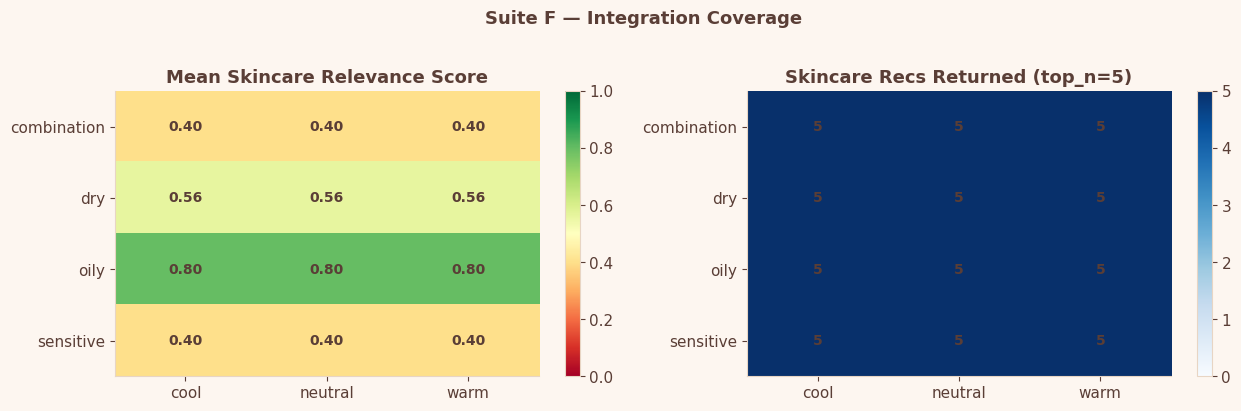

📊 Saved → reports/F_integration_heatmap.png


In [11]:
# ── Coverage heatmap ──────────────────────────────────────────────────────────
if combo_stats:
    df_c = pd.DataFrame(combo_stats)
    pivot_s = df_c.pivot(index='skin_type', columns='undertone', values='mean_score')
    pivot_n = df_c.pivot(index='skin_type', columns='undertone', values='n_sk')

    fig, axes = plt.subplots(1, 2, figsize=(13,4))
    for ax, pivot, title, cmap in zip(
        axes,
        [pivot_s, pivot_n],
        ['Mean Skincare Relevance Score', 'Skincare Recs Returned (top_n=5)'],
        ['RdYlGn', 'Blues']
    ):
        vmax = 1 if 'Score' in title else None
        im = ax.imshow(pivot.values, cmap=cmap, aspect='auto',
                       vmin=0, vmax=vmax)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_yticks(range(len(pivot.index)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticklabels(pivot.index)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                v = pivot.values[i,j]
                ax.text(j, i, f'{v:.2f}' if 'Score' in title else str(int(v)),
                        ha='center', va='center', fontsize=10, fontweight='bold')
        ax.set_title(title)
        plt.colorbar(im, ax=ax)

    plt.suptitle('Suite F — Integration Coverage', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(REPORTS_DIR/'F_integration_heatmap.png', dpi=150, bbox_inches='tight',
                facecolor=plt.rcParams['figure.facecolor'])
    plt.show()
    print('📊 Saved → reports/F_integration_heatmap.png')

---
## Suite G — Edge-Case & Guard Tests

In [12]:
G = SUITES['G'] = TestSuite('G', 'Edge-Case & Guard Tests')

# ── G1: All invalid skin_type values ─────────────────────────────────────────
G.group('Invalid skin_type strings')
# '' is intentionally allowed by the engine (== "not provided"), so excluded
for bad in ['greasy','oily ','OILY','Oily','normal','all','None']:
    G.check_raises(f'skin_type={repr(bad)} → ValueError',
        lambda b=bad: engine._validate(b, [], None), ValueError)

# ── G2: All invalid concerns ──────────────────────────────────────────────────
G.group('Invalid concern strings')
for bad in ['wrinkles','breakouts','dark spots','ACNE','oily']:
    G.check_raises(f'concern={repr(bad)} → ValueError',
        lambda b=bad: engine._validate('oily', [b], None), ValueError)

# ── G3: All invalid undertone values ─────────────────────────────────────────
G.group('Invalid undertone strings')
# '' is intentionally allowed by the engine (== "not provided"), so excluded
for bad in ['pink','olive','WARM','Warm','golden']:
    G.check_raises(f'undertone={repr(bad)} → ValueError',
        lambda b=bad: engine._validate('oily', [], b), ValueError)

# ── G4: None / missing optional params ───────────────────────────────────────
G.group('None values for optional parameters')
try:
    r = engine.recommend('oily', concerns=None, undertone='warm')
    G.check('concerns=None: no crash',           True)
    G.check('concerns=None → stored as []',      r['user_profile']['concerns'] == [])
except Exception as e:
    G.check('concerns=None: unexpected crash',   False, str(e))

try:
    r = engine.recommend('dry', concerns=[], undertone=None, skin_tone=None)
    G.check('undertone=None: no crash',          True)
    G.check('undertone=None → makeup_recs=[]',   r['makeup_recommendations'] == [])
    G.check('undertone=None → colour_palette={}', r['colour_palette'] == {})
    G.check('skin_tone=None stored',             r['user_profile']['skin_tone'] is None)
except Exception as e:
    G.check('undertone=None: unexpected crash',  False, str(e))

# ── G5: Empty DataFrames ──────────────────────────────────────────────────────
G.group('Engine with completely empty DataFrames')
e_empty = PureGlowRecommendationEngine(pd.DataFrame(), pd.DataFrame(), COLOUR_CONFIG)
try:
    r = e_empty.recommend('oily', ['acne'], 'warm', top_n=5)
    G.check('empty DFs: recommend() no crash',   True)
    G.check('empty DFs: skincare_recs=[]',        r['skincare_recommendations'] == [])
    G.check('empty DFs: makeup_recs=[]',          r['makeup_recommendations'] == [])
    G.check('empty DFs: colour_palette returned', isinstance(r['colour_palette'], dict))
except Exception as e:
    G.check('empty DFs: unexpected crash',        False, str(e))

# ── G6: Single-row DataFrames ─────────────────────────────────────────────────
G.group('Engine with single-row DataFrames')
e_one = PureGlowRecommendationEngine(SK_FIX.head(1), MK_FIX.head(1), COLOUR_CONFIG)
try:
    r = e_one.recommend('oily', ['acne'], 'warm', top_n=10)
    G.check('1-row DFs: no crash',               True)
    G.check('1-row DFs: skincare count ≤ 1',     len(r['skincare_recommendations']) <= 1)
    G.check('1-row DFs: makeup count ≤ 1',       len(r['makeup_recommendations']) <= 1)
except Exception as e:
    G.check('1-row DFs: unexpected crash',        False, str(e))

# ── G7: Missing columns in DataFrames ────────────────────────────────────────
G.group('DataFrames with missing optional columns')
SK_NO_URL    = SK_FIX.drop(columns=['url'])
SK_NO_PRICE  = SK_FIX.drop(columns=['price'])
SK_NO_RATING = SK_FIX.drop(columns=['rating'])

for label, df in [('no url',SK_NO_URL),('no price',SK_NO_PRICE),('no rating',SK_NO_RATING)]:
    e_miss = PureGlowRecommendationEngine(df, MK_FIX, COLOUR_CONFIG)
    try:
        r = e_miss.recommend('oily',['acne'],'warm')
        G.check(f'skincare {label}: no crash', True)
    except Exception as e:
        G.check(f'skincare {label}: crashed', False, str(e)[:50])

G.summary()

[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=None, undertone=warm, top_n=5)
[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=dry, concerns=[], undertone=None, top_n=5)
[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=5)
[18:34:08] pureglow.recommendation_engine WARNING: skincare_df is empty -- returning empty result
[18:34:08] pureglow.recommendation_engine WARNING: makeup_df is empty -- returning empty result
[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=10)
[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=5)
[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=5)
[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm,


══════════════════════════════════════════════════════════════════════
  SUITE G — Edge-Case & Guard Tests
══════════════════════════════════════════════════════════════════════

  ── Invalid skin_type strings
    ✓ skin_type='greasy' → ValueError  (Invalid skin_type 'greasy'. Choose from: ['oily', 'dry', 'co)
    ✓ skin_type='oily ' → ValueError  (Invalid skin_type 'oily '. Choose from: ['oily', 'dry', 'com)
    ✓ skin_type='OILY' → ValueError  (Invalid skin_type 'OILY'. Choose from: ['oily', 'dry', 'comb)
    ✓ skin_type='Oily' → ValueError  (Invalid skin_type 'Oily'. Choose from: ['oily', 'dry', 'comb)
    ✓ skin_type='normal' → ValueError  (Invalid skin_type 'normal'. Choose from: ['oily', 'dry', 'co)
    ✓ skin_type='all' → ValueError  (Invalid skin_type 'all'. Choose from: ['oily', 'dry', 'combi)
    ✓ skin_type='None' → ValueError  (Invalid skin_type 'None'. Choose from: ['oily', 'dry', 'comb)

  ── Invalid concern strings
    ✓ concern='wrinkles' → ValueError  (Invalid concern

{'total': 33, 'passed': 33, 'warned': 0, 'failed': 0}

---
## Suite H — Data Quality Tests
Validates the real `skincare_products.csv` and `makeup_products.csv` saved by notebook 03.


══════════════════════════════════════════════════════════════════════
  SUITE H — Data Quality Tests
══════════════════════════════════════════════════════════════════════

  ── skincare_products.csv — shape and required columns
    ✓ at least 100 skincare products  (3,474)
    ✓ has column: product_id
    ✓ has column: name
    ✓ has column: brand
    ✓ has column: category
    ✓ has column: source
    ✓ has column: product_kind
    ✓ has skin tag: skin_oily
    ✓ has skin tag: skin_dry
    ✓ has skin tag: skin_combination
    ✓ has skin tag: skin_sensitive
    ✓ has concern tag: concern_acne
    ✓ has concern tag: concern_dark_spots
    ✓ has concern tag: concern_redness
    ✓ has concern tag: concern_dullness
    ✓ has concern tag: concern_aging
    ✓ has concern tag: concern_dryness

  ── skincare_products.csv — data integrity
    ✓ name null% < 5%  (0.0%)
    ✓ no duplicate product_ids  (0.0% dups)
    ✓ no negative prices  (0 negative)
    ✓ ratings in [0,5]  (min=nan max=nan)


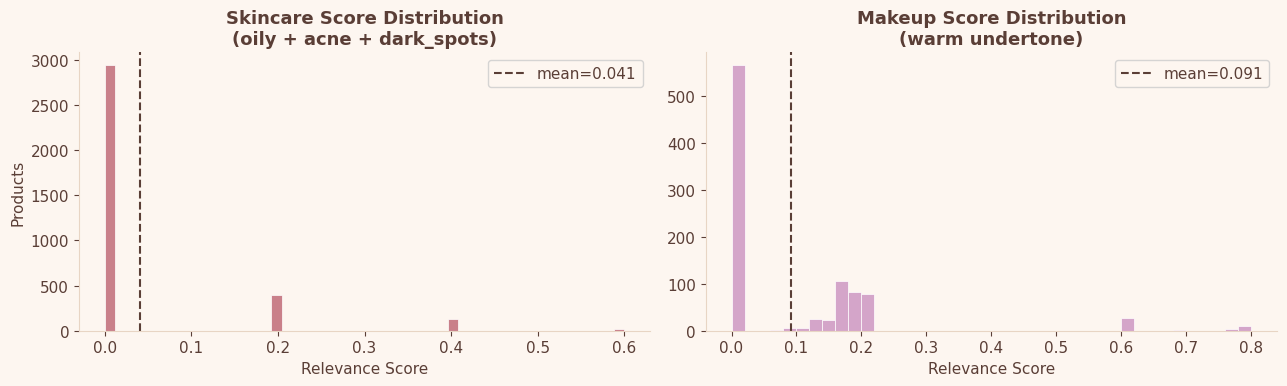


  ↳ 72/72 passed (100%)  |  0 failed  |  0 warnings


{'total': 72, 'passed': 72, 'warned': 0, 'failed': 0}

In [13]:
H = SUITES['H'] = TestSuite('H', 'Data Quality Tests')

sk_df = engine.skincare_df
mk_df = engine.makeup_df

# ── H1: Skincare product table ────────────────────────────────────────────────
H.group('skincare_products.csv — shape and required columns')
H.check('at least 100 skincare products', len(sk_df) >= 100, f'{len(sk_df):,}')
for col in ['product_id','name','brand','category','source','product_kind']:
    H.check(f'has column: {col}', col in sk_df.columns)
for col in ['skin_oily','skin_dry','skin_combination','skin_sensitive']:
    H.check(f'has skin tag: {col}', col in sk_df.columns)
for col in ['concern_acne','concern_dark_spots','concern_redness',
             'concern_dullness','concern_aging','concern_dryness']:
    H.check(f'has concern tag: {col}', col in sk_df.columns)

H.group('skincare_products.csv — data integrity')
if 'name' in sk_df.columns:
    null_name_pct = sk_df['name'].isnull().mean()*100
    H.check('name null% < 5%', null_name_pct < 5, f'{null_name_pct:.1f}%')
if 'product_id' in sk_df.columns:
    dup_pct = sk_df['product_id'].duplicated().mean()*100
    H.check('no duplicate product_ids', dup_pct == 0, f'{dup_pct:.1f}% dups')
if 'price' in sk_df.columns:
    neg = (pd.to_numeric(sk_df['price'],errors='coerce') < 0).sum()
    H.check('no negative prices', neg == 0, f'{neg} negative')
if 'rating' in sk_df.columns:
    r = pd.to_numeric(sk_df['rating'],errors='coerce').dropna()
    H.check('ratings in [0,5]', r.between(0,5).all(),
            f'min={r.min():.2f} max={r.max():.2f}')
if 'product_kind' in sk_df.columns:
    wrong = (sk_df['product_kind'] != 'skincare').sum()
    H.check('all product_kind=skincare', wrong == 0, f'{wrong} wrong')

H.group('skincare_products.csv — tag coverage (> 0% means engine can match)')
for tag in ['skin_oily','skin_dry','skin_combination','skin_sensitive',
             'concern_acne','concern_dark_spots','concern_redness',
             'concern_dullness','concern_aging','concern_dryness']:
    if tag in sk_df.columns:
        pct = sk_df[tag].mean()*100
        H.check(f'{tag} coverage > 0%', pct > 0, f'{pct:.1f}%', warn=True)

# ── H2: Makeup product table ──────────────────────────────────────────────────
H.group('makeup_products.csv — shape and columns')
if mk_df.empty:
    H.check('makeup data available', False, 'empty DataFrame', warn=True)
else:
    H.check('at least 50 makeup products', len(mk_df) >= 50, f'{len(mk_df):,}', warn=True)
    for col in ['product_id','name','brand','product_type','product_kind']:
        H.check(f'has column: {col}', col in mk_df.columns)
    for col in ['undertone_warm','undertone_cool','undertone_neutral']:
        H.check(f'has undertone tag: {col}', col in mk_df.columns)
    
    if all(c in mk_df.columns for c in ['undertone_warm','undertone_cool','undertone_neutral']):
        no_tag = ~(mk_df['undertone_warm']|mk_df['undertone_cool']|mk_df['undertone_neutral'])
        H.check('no untagged makeup products (neutral fallback applied)',
                no_tag.sum() == 0, f'{no_tag.sum()} untagged')

# ── H3: colour_config.json ───────────────────────────────────────────────────
H.group('colour_config.json — all undertones and product types')
cfg = engine.colour_config
for ut in ['warm','cool','neutral']:
    H.check(f'{ut} key present', ut in cfg)
    if ut in cfg:
        for pt in ['blush','lipstick','eyeshadow','highlighter','foundation']:
            H.check(f'{ut}.{pt} has shades',
                    pt in cfg[ut] and len(cfg[ut][pt]) > 0,
                    f'{len(cfg[ut].get(pt,[]))} shades')

# ── H4: keyword_maps.json ─────────────────────────────────────────────────────
H.group('keyword_maps.json — all maps present and non-empty')
kw_path = MODELS_DIR / 'keyword_maps.json'
if kw_path.exists():
    with open(kw_path) as f:
        kw_maps = json.load(f)
    for key in ['skin_type_keywords','concern_keywords','undertone_keywords']:
        H.check(f'{key} present', key in kw_maps)
        if key in kw_maps:
            H.check(f'{key} non-empty', len(kw_maps[key]) > 0)
            H.check(f'{key} all lists non-empty',
                    all(len(v)>0 for v in kw_maps[key].values()))
else:
    H.check('keyword_maps.json exists', False, warn=True)

# ── H5: Score distribution on real data ──────────────────────────────────────
H.group('Score distribution sanity (real skincare data)')
real_scored = score_skincare(sk_df, 'oily', ['acne','dark_spots'])
sc = real_scored['relevance_score']
H.check('all scores in [0,1]',          sc.between(0,1).all(),
        f'min={sc.min():.4f} max={sc.max():.4f}')
H.check('score std > 0 (not all same)', sc.std() > 0, f'std={sc.std():.4f}')
H.check('top score > 0.1',              sc.max() > 0.1, f'max={sc.max():.4f}')

# Score distribution charts
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].hist(sc, bins=50, color='#c9808a', edgecolor='white', linewidth=0.5)
axes[0].axvline(sc.mean(),color='#5a3e36',linestyle='--',linewidth=1.5,label=f'mean={sc.mean():.3f}')
axes[0].set_title('Skincare Score Distribution\n(oily + acne + dark_spots)')
axes[0].set_xlabel('Relevance Score'); axes[0].set_ylabel('Products'); axes[0].legend()

if not mk_df.empty and 'undertone_warm' in mk_df.columns:
    mk_sc = score_makeup(mk_df,'warm')['relevance_score']
    axes[1].hist(mk_sc, bins=40, color='#d4a5c9', edgecolor='white', linewidth=0.5)
    axes[1].axvline(mk_sc.mean(),color='#5a3e36',linestyle='--',linewidth=1.5,
                    label=f'mean={mk_sc.mean():.3f}')
    axes[1].set_title('Makeup Score Distribution\n(warm undertone)')
    axes[1].set_xlabel('Relevance Score'); axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR/'H_score_distributions.png', dpi=150, bbox_inches='tight',
            facecolor=plt.rcParams['figure.facecolor'])
plt.show()
H.summary()

---
## Suite I — Performance Tests
Benchmarks latency against Flask API SLAs.

[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne', 'dark_spots'], undertone=warm, top_n=10)
[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne', 'dark_spots'], undertone=warm, top_n=10)
[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne', 'dark_spots'], undertone=warm, top_n=10)
[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne', 'dark_spots'], undertone=warm, top_n=10)
[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne', 'dark_spots'], undertone=warm, top_n=10)
[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne', 'dark_spots'], undertone=warm, top_n=10)
[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne', 'dark_spots'], undertone=warm, top_n=10)
[18:34:08] pureglow.recommendation_engine INFO: recommend(skin_type=o


══════════════════════════════════════════════════════════════════════
  SUITE I — Performance Tests
══════════════════════════════════════════════════════════════════════

  ── Single recommend() — 20 runs
    ✓ mean < 200ms  (mean=7.17ms min=5.81ms max=9.65ms)
    ✓ max < 600ms (no outlier spike)  (max=9.65ms)

  ── Batch 10 sequential calls


[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=combination, concerns=['acne'], undertone=warm, top_n=5)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=sensitive, concerns=['redness'], undertone=cool, top_n=5)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['aging'], undertone=neutral, top_n=5)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=dry, concerns=['dark_spots'], undertone=warm, top_n=5)
[18:34:09] pureglow.recommendation_engine INFO: Loaded skincare: 3474 products from C:\Users\HP\OneDrive\Desktop\PureGlow AI\models\skincare_products.csv
[18:34:09] pureglow.recommendation_engine INFO: Loaded makeup: 931 products from C:\Users\HP\OneDrive\Desktop\PureGlow AI\models\makeup_products.csv
[18:34:09] pureglow.recommendation_engine INFO: Loaded skincare: 3474 products from C:\Users\HP\OneDrive\Desktop\PureGlow AI\models\skincare_products.csv
[18:34:09] pureglow.recommendation_engine INFO:

    ✓ batch 10 < 1500ms  (103.81ms total  (10.4ms avg))

  ── Individual method latency — 20 runs each
    ✓ get_skincare < 100ms  (2.31ms)
    ✓ get_makeup < 100ms  (2.31ms)
    ✓ get_colour_palette < 5ms  (0.0ms)

  ── load_engine() cold start — 3 runs
    ✓ load_engine < 4000ms  (21ms)


[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=dry, concerns=['redness'], undertone=cool, top_n=5)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=dry, concerns=['redness'], undertone=cool, top_n=5)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=dry, concerns=['redness'], undertone=cool, top_n=5)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=dry, concerns=['redness'], undertone=cool, top_n=5)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=combination, concerns=['dark_spots'], undertone=neutral, top_n=5)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=combination, concerns=['dark_spots'], undertone=neutral, top_n=5)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=combination, concerns=['dark_spots'], undertone=neutral, top_n=5)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=combination, concerns=['dark_spots'], undertone=ne

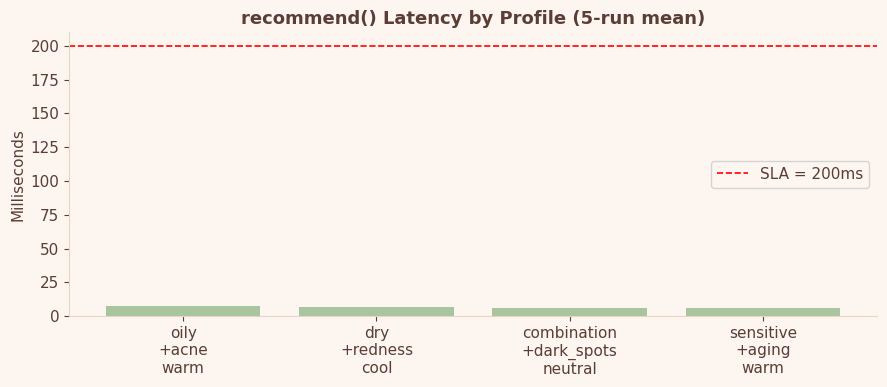


  ↳ 7/7 passed (100%)  |  0 failed  |  0 warnings


{'total': 7, 'passed': 7, 'warned': 0, 'failed': 0}

In [14]:
I_suite = SUITES['I'] = TestSuite('I', 'Performance Tests')

# SLA targets (milliseconds) — chosen for a Flask endpoint budget
SLA = {
    'single_recommend':  200,   # one recommend() call
    'batch_10':         1500,   # 10 sequential calls (simulate 10 concurrent users)
    'load_engine':      4000,   # cold-start from disk
    'get_skincare':      100,   # skincare-only call
    'get_makeup':        100,   # makeup-only call
}

def bench(fn, n=10):
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        fn()
        times.append((time.perf_counter()-t0)*1000)
    return round(np.mean(times),2), round(np.min(times),2), round(np.max(times),2)

# ── I1: Single recommend() ────────────────────────────────────────────────────
I_suite.group('Single recommend() — 20 runs')
mean_ms, min_ms, max_ms = bench(
    lambda: engine.recommend('oily',['acne','dark_spots'],'warm',top_n=10), n=20)
I_suite.check(f'mean < {SLA["single_recommend"]}ms',
              mean_ms < SLA['single_recommend'],
              f'mean={mean_ms}ms min={min_ms}ms max={max_ms}ms')
I_suite.check(f'max < {SLA["single_recommend"]*3}ms (no outlier spike)',
              max_ms < SLA['single_recommend']*3, f'max={max_ms}ms')

# ── I2: Batch of 10 profiles ──────────────────────────────────────────────────
I_suite.group('Batch 10 sequential calls')
batch_profiles = [
    dict(skin_type=st, concerns=[c], undertone=ut, top_n=5)
    for st,c,ut in zip(
        ['oily','dry','combination','sensitive','oily',
         'dry','combination','sensitive','oily','dry'],
        ['acne','redness','dark_spots','aging','dullness',
         'dryness','acne','redness','aging','dark_spots'],
        ['warm','cool','neutral','warm','cool',
         'neutral','warm','cool','neutral','warm']
    )
]
t0 = time.perf_counter()
for p in batch_profiles: engine.recommend(**p)
batch_ms = round((time.perf_counter()-t0)*1000, 2)
I_suite.check(f'batch 10 < {SLA["batch_10"]}ms',
              batch_ms < SLA['batch_10'],
              f'{batch_ms}ms total  ({batch_ms/10:.1f}ms avg)')

# ── I3: Individual methods ────────────────────────────────────────────────────
I_suite.group('Individual method latency — 20 runs each')
sk_mean,_,_ = bench(lambda: engine.get_skincare('dry',['redness'],top_n=10), n=20)
mk_mean,_,_ = bench(lambda: engine.get_makeup('cool',top_n=10), n=20)
pl_mean,_,_ = bench(lambda: engine.get_colour_palette('neutral'), n=20)
I_suite.check(f'get_skincare < {SLA["get_skincare"]}ms',  sk_mean < SLA['get_skincare'], f'{sk_mean}ms')
I_suite.check(f'get_makeup < {SLA["get_makeup"]}ms',      mk_mean < SLA['get_makeup'],   f'{mk_mean}ms')
I_suite.check('get_colour_palette < 5ms',                  pl_mean < 5,                  f'{pl_mean}ms')

# ── I4: load_engine() cold start ─────────────────────────────────────────────
I_suite.group('load_engine() cold start — 3 runs')
cold_mean,_,_ = bench(load_engine, n=3)
I_suite.check(f'load_engine < {SLA["load_engine"]}ms',
              cold_mean < SLA['load_engine'], f'{cold_mean:.0f}ms')

# ── Latency chart ─────────────────────────────────────────────────────────────
latencies = []
for st,c,ut in [('oily','acne','warm'),('dry','redness','cool'),
                 ('combination','dark_spots','neutral'),('sensitive','aging','warm')]:
    m,_,_ = bench(lambda st=st,c=c,ut=ut: engine.recommend(st,[c],ut), n=5)
    latencies.append({'profile':f'{st}\n+{c}\n{ut}','ms':m})

df_lat = pd.DataFrame(latencies)
fig, ax = plt.subplots(figsize=(9,4))
cols = [C_PASS if v < SLA['single_recommend'] else C_FAIL for v in df_lat['ms']]
ax.bar(df_lat['profile'], df_lat['ms'], color=cols)
ax.axhline(SLA['single_recommend'], color='red', linestyle='--', linewidth=1.2,
           label=f'SLA = {SLA["single_recommend"]}ms')
ax.set_title('recommend() Latency by Profile (5-run mean)')
ax.set_ylabel('Milliseconds'); ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR/'I_latency.png', dpi=150, bbox_inches='tight',
            facecolor=plt.rcParams['figure.facecolor'])
plt.show()
I_suite.summary()

---
## Suite J — Regression Tests
Golden fixtures with hardcoded expected outputs — re-run after every code change.

In [15]:
J = SUITES['J'] = TestSuite('J', 'Regression Tests — Golden Fixtures')

# All regression tests use the fully controlled fixture engine
# so results are deterministic regardless of real data changes
reg = PureGlowRecommendationEngine(SK_FIX, MK_FIX, COLOUR_CONFIG)

# ── J1: oily + acne + warm ────────────────────────────────────────────────────
J.group('Golden set 1: oily + acne + warm')
g1 = reg.recommend('oily', ['acne'], 'warm', skin_tone='medium', top_n=3)

J.check('skincare[0] is sk_0',
        g1['skincare_recommendations'][0]['product_id'] == 'sk_0',
        f"got: {g1['skincare_recommendations'][0].get('product_id')}")
J.check('skincare[0] score = 1.0000',
        abs(g1['skincare_recommendations'][0]['relevance_score'] - 1.0) < 0.0001,
        f"got: {g1['skincare_recommendations'][0]['relevance_score']:.4f}")
J.check('skincare[-1] is sk_2 (no-match last)',
        g1['skincare_recommendations'][-1]['product_id'] == 'sk_2',
        f"got: {g1['skincare_recommendations'][-1].get('product_id')}")
J.check('makeup[0] is mk_0 (warm)',
        g1['makeup_recommendations'][0]['product_id'] == 'mk_0',
        f"got: {g1['makeup_recommendations'][0].get('product_id')}")
J.check('colour_palette has 5 product types',
        len(g1['colour_palette']) == 5,
        f"got: {len(g1['colour_palette'])}")
J.check('user_profile exact match',
        g1['user_profile'] == {'skin_type':'oily','concerns':['acne'],
                                'undertone':'warm','skin_tone':'medium'})

# ── J2: dry + redness + dryness + cool ───────────────────────────────────────
J.group('Golden set 2: dry + redness + dryness + cool')
g2 = reg.recommend('dry', ['redness','dryness'], 'cool', top_n=3)

J.check('skincare[0] is sk_1',
        g2['skincare_recommendations'][0]['product_id'] == 'sk_1',
        f"got: {g2['skincare_recommendations'][0].get('product_id')}")
# Expected: skin_dry(0.40) + concern_redness(0.20) + concern_dryness(0.20) + (4.2/4.8)*0.20
expected_g2 = round(0.40 + 0.20 + 0.20 + (4.2/4.8)*0.20, 4)
actual_g2   = g2['skincare_recommendations'][0]['relevance_score']
J.check(f'skincare[0] score = {expected_g2}',
        abs(actual_g2 - expected_g2) < 0.0001,
        f'expected={expected_g2} got={actual_g2:.4f}')
J.check('makeup[0] is mk_1 (cool)',
        g2['makeup_recommendations'][0]['product_id'] == 'mk_1',
        f"got: {g2['makeup_recommendations'][0].get('product_id')}")

# ── J3: sensitive + aging + neutral ───────────────────────────────────────────
J.group('Golden set 3: sensitive + aging + neutral')
g3 = reg.recommend('sensitive', ['aging'], 'neutral', top_n=3)

J.check('makeup[0] is mk_2 (neutral)',
        g3['makeup_recommendations'][0]['product_id'] == 'mk_2',
        f"got: {g3['makeup_recommendations'][0].get('product_id')}")

# ── J4: Determinism — same inputs always give same outputs ────────────────────
J.group('Determinism — identical inputs produce identical outputs')
r_a = reg.recommend('oily', ['acne','dark_spots'], 'warm', top_n=5)
r_b = reg.recommend('oily', ['acne','dark_spots'], 'warm', top_n=5)
# The detailed engine adds metadata.generated_at timestamp -- strip before compare
def _strip_meta(d):
    return {k: v for k, v in d.items() if k != 'metadata'}
J.check('result dicts are equal (excluding timestamp metadata)', _strip_meta(r_a) == _strip_meta(r_b))
J.check('scores are identical',
        [x['relevance_score'] for x in r_a['skincare_recommendations']] ==
        [x['relevance_score'] for x in r_b['skincare_recommendations']])

# ── J5: Rank stability — relative ordering never changes ─────────────────────
J.group('Rank stability — sk_0 always beats sk_1 and sk_2 for oily+acne')
s = score_skincare(SK_FIX, 'oily', ['acne'])
idx = {row['product_id']: row['relevance_score'] for _, row in s.iterrows()}
J.check('score(sk_0) > score(sk_1)', idx['sk_0'] > idx['sk_1'],
        f'{idx["sk_0"]:.4f} vs {idx["sk_1"]:.4f}')
J.check('score(sk_0) > score(sk_2)', idx['sk_0'] > idx['sk_2'],
        f'{idx["sk_0"]:.4f} vs {idx["sk_2"]:.4f}')
J.check('score(sk_1) > score(sk_2)', idx['sk_1'] > idx['sk_2'],
        f'{idx["sk_1"]:.4f} vs {idx["sk_2"]:.4f}')

# ── J6: VALID_* class constants unchanged ────────────────────────────────────
J.group('VALID_* class constants match notebook 03 definitions')
J.check('VALID_SKIN_TYPES',
        PureGlowRecommendationEngine.VALID_SKIN_TYPES == ['oily','dry','combination','sensitive'],
        str(PureGlowRecommendationEngine.VALID_SKIN_TYPES))
J.check('VALID_CONCERNS',
        PureGlowRecommendationEngine.VALID_CONCERNS == ['acne','dark_spots','redness','dullness','aging','dryness'],
        str(PureGlowRecommendationEngine.VALID_CONCERNS))
J.check('VALID_UNDERTONES',
        PureGlowRecommendationEngine.VALID_UNDERTONES == ['warm','cool','neutral'],
        str(PureGlowRecommendationEngine.VALID_UNDERTONES))

J.summary()

[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne'], undertone=warm, top_n=3)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=dry, concerns=['redness', 'dryness'], undertone=cool, top_n=3)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=sensitive, concerns=['aging'], undertone=neutral, top_n=3)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne', 'dark_spots'], undertone=warm, top_n=5)
[18:34:09] pureglow.recommendation_engine INFO: recommend(skin_type=oily, concerns=['acne', 'dark_spots'], undertone=warm, top_n=5)



══════════════════════════════════════════════════════════════════════
  SUITE J — Regression Tests — Golden Fixtures
══════════════════════════════════════════════════════════════════════

  ── Golden set 1: oily + acne + warm
    ✓ skincare[0] is sk_0  (got: sk_0)
    ✓ skincare[0] score = 1.0000  (got: 1.0000)
    ✓ skincare[-1] is sk_2 (no-match last)  (got: sk_2)
    ✓ makeup[0] is mk_0 (warm)  (got: mk_0)
    ✓ colour_palette has 5 product types  (got: 5)
    ✓ user_profile exact match

  ── Golden set 2: dry + redness + dryness + cool
    ✓ skincare[0] is sk_1  (got: sk_1)
    ✓ skincare[0] score = 0.975  (expected=0.975 got=0.9750)
    ✓ makeup[0] is mk_1 (cool)  (got: mk_1)

  ── Golden set 3: sensitive + aging + neutral
    ✓ makeup[0] is mk_2 (neutral)  (got: mk_2)

  ── Determinism — identical inputs produce identical outputs
    ✓ result dicts are equal (excluding timestamp metadata)
    ✓ scores are identical

  ── Rank stability — sk_0 always beats sk_1 and sk_2 for oil

{'total': 18, 'passed': 18, 'warned': 0, 'failed': 0}

---
## Suite K — Report

In [16]:
# ── Aggregate ─────────────────────────────────────────────────────────────────
all_results = [r for s in SUITES.values() for r in s.results]
df_all      = pd.DataFrame(all_results)

total   = len(df_all)
passed  = (df_all['status']=='PASS').sum()
warned  = (df_all['status']=='WARN').sum()
failed  = (df_all['status']=='FAIL').sum()
pct     = passed/total*100 if total else 0

print('\n' + '═'*70)
print('  FINAL TEST REPORT')
print('═'*70)
print(f'  Timestamp  : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'  Total      : {total}')
print(f'  ✓ Passed   : {passed}  ({pct:.1f}%)')
print(f'  ⚠ Warnings : {warned}')
print(f'  ✗ Failed   : {failed}')
print()
print('  Per-suite:')
for lbl, suite in SUITES.items():
    sm   = suite.summary()
    bar  = '█' * int(sm['passed']/max(sm['total'],1)*20)
    f_s  = f'  ✗{sm["failed"]}' if sm['failed']  else ''
    w_s  = f'  ⚠{sm["warned"]}' if sm['warned']  else ''
    print(f'    {lbl} {suite.name:<32} {sm["passed"]:>3}/{sm["total"]:>3}  [{bar:<20}]{f_s}{w_s}')

print()
if failed == 0:
    print('  ✅ ALL TESTS PASSED — Engine is ready for Flask integration!')
else:
    print(f'  ❌ {failed} TESTS FAILED — Fix before integrating into Flask:')
    fail_df = df_all[df_all['status']=='FAIL'][['suite','group','test','detail']]
    display(fail_df.reset_index(drop=True))
print('═'*70)


══════════════════════════════════════════════════════════════════════
  FINAL TEST REPORT
══════════════════════════════════════════════════════════════════════
  Timestamp  : 2026-05-09 18:34:09
  Total      : 412
  ✓ Passed   : 411  (99.8%)
  ⚠ Warnings : 1
  ✗ Failed   : 0

  Per-suite:

  ↳ 23/23 passed (100%)  |  0 failed  |  0 warnings
    A File & Import Checks              23/ 23  [████████████████████]

  ↳ 56/57 passed (98%)  |  0 failed  |  1 warnings
    B Cleaned Data Checks (01_data_cleaning outputs)  56/ 57  [███████████████████ ]  ⚠1

  ↳ 37/37 passed (100%)  |  0 failed  |  0 warnings
    C Helper Function Tests             37/ 37  [████████████████████]

  ↳ 26/26 passed (100%)  |  0 failed  |  0 warnings
    D Scoring Function Tests            26/ 26  [████████████████████]

  ↳ 67/67 passed (100%)  |  0 failed  |  0 warnings
    E Engine Method Tests               67/ 67  [████████████████████]

  ↳ 72/72 passed (100%)  |  0 failed  |  0 warnings
    F Integration


  ↳ 23/23 passed (100%)  |  0 failed  |  0 warnings

  ↳ 56/57 passed (98%)  |  0 failed  |  1 warnings

  ↳ 37/37 passed (100%)  |  0 failed  |  0 warnings

  ↳ 26/26 passed (100%)  |  0 failed  |  0 warnings

  ↳ 67/67 passed (100%)  |  0 failed  |  0 warnings

  ↳ 72/72 passed (100%)  |  0 failed  |  0 warnings

  ↳ 33/33 passed (100%)  |  0 failed  |  0 warnings

  ↳ 72/72 passed (100%)  |  0 failed  |  0 warnings

  ↳ 7/7 passed (100%)  |  0 failed  |  0 warnings

  ↳ 18/18 passed (100%)  |  0 failed  |  0 warnings

  ↳ 23/23 passed (100%)  |  0 failed  |  0 warnings

  ↳ 56/57 passed (98%)  |  0 failed  |  1 warnings

  ↳ 37/37 passed (100%)  |  0 failed  |  0 warnings

  ↳ 26/26 passed (100%)  |  0 failed  |  0 warnings

  ↳ 67/67 passed (100%)  |  0 failed  |  0 warnings

  ↳ 72/72 passed (100%)  |  0 failed  |  0 warnings

  ↳ 33/33 passed (100%)  |  0 failed  |  0 warnings

  ↳ 72/72 passed (100%)  |  0 failed  |  0 warnings

  ↳ 7/7 passed (100%)  |  0 failed  |  0 warnings

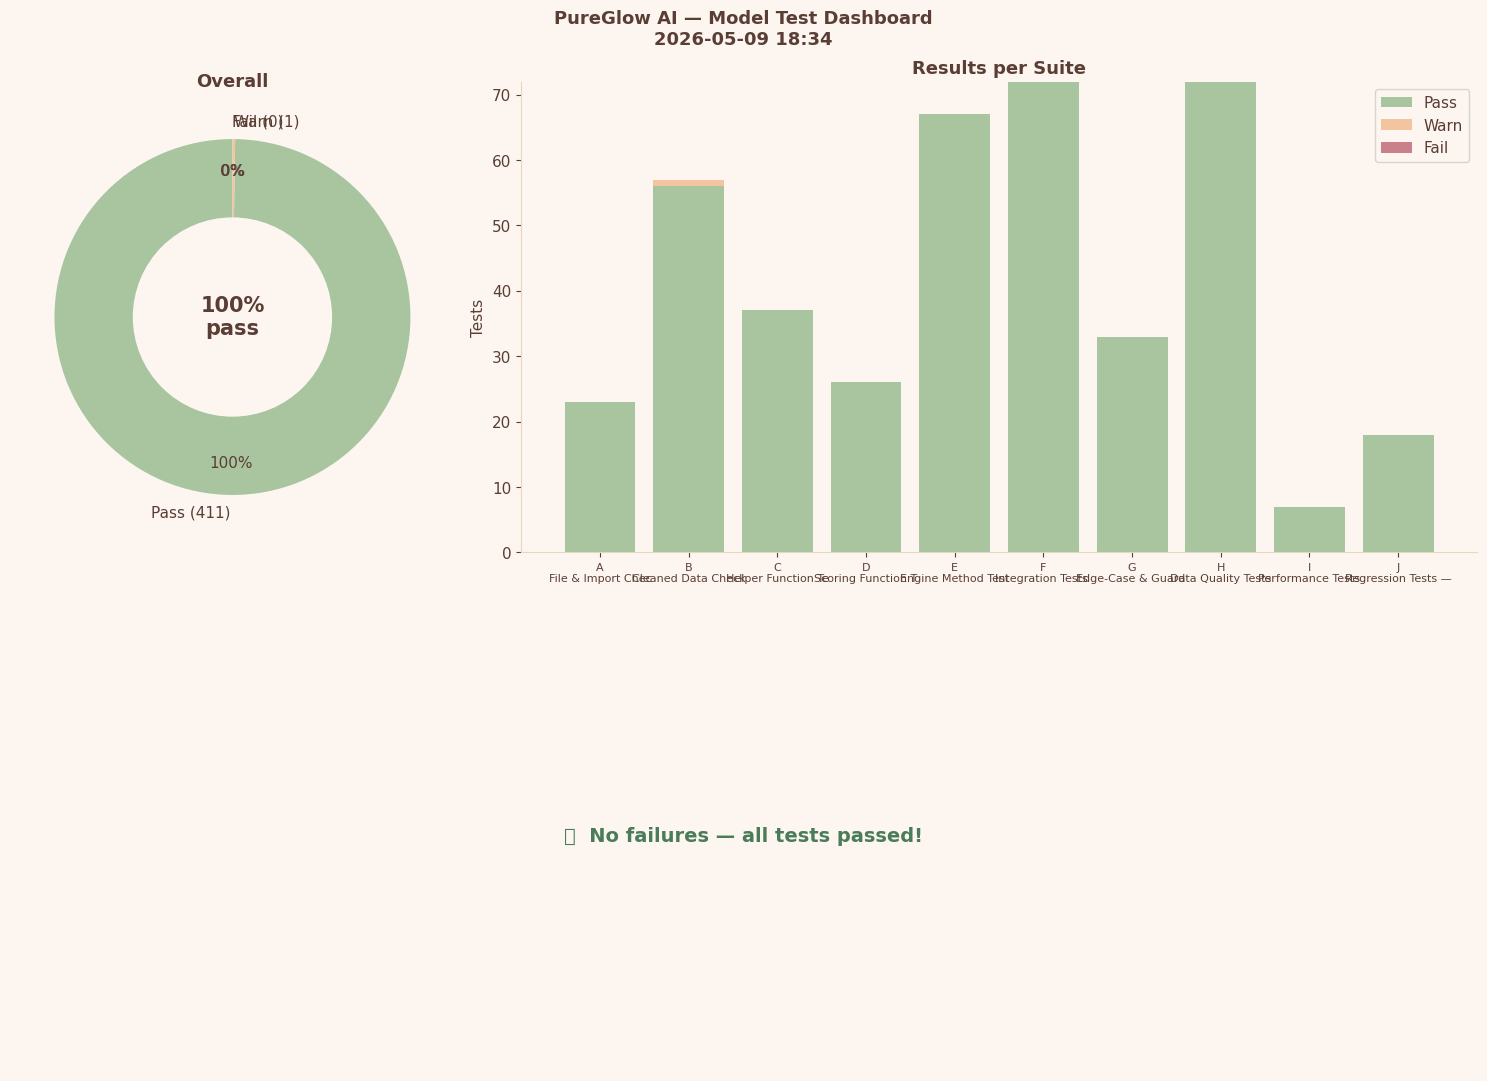

📊 Dashboard saved → reports/K_test_dashboard.png


In [17]:
# ── Visual dashboard ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 11))

# 1 — Overall donut
ax1 = fig.add_subplot(2, 3, 1)
sizes  = [max(s,0.001) for s in [passed, warned, failed]]
labels = [f'Pass ({passed})', f'Warn ({warned})', f'Fail ({failed})']
wedges,_,autotexts = ax1.pie(sizes, labels=labels, colors=[C_PASS,C_WARN,C_FAIL],
                               autopct='%1.0f%%', startangle=90, pctdistance=0.82)
ax1.add_patch(plt.Circle((0,0),0.56,fc=plt.rcParams['figure.facecolor']))
ax1.text(0, 0, f'{pct:.0f}%\npass', ha='center', va='center',
         fontsize=15, fontweight='bold', color='#5a3e36')
ax1.set_title('Overall')

# 2 — Per-suite stacked bar
ax2 = fig.add_subplot(2, 3, (2,3))
lbls  = list(SUITES.keys())
names = [SUITES[k].name for k in lbls]
pv    = [SUITES[k].summary()['passed']  for k in lbls]
wv    = [SUITES[k].summary()['warned']  for k in lbls]
fv    = [SUITES[k].summary()['failed']  for k in lbls]
x = range(len(lbls))
ax2.bar(x, pv, color=C_PASS, label='Pass')
ax2.bar(x, wv, bottom=pv, color=C_WARN, label='Warn')
ax2.bar(x, fv, bottom=[p+w for p,w in zip(pv,wv)], color=C_FAIL, label='Fail')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{k}\n{n[:18]}' for k,n in zip(lbls,names)], fontsize=8)
ax2.set_title('Results per Suite'); ax2.set_ylabel('Tests'); ax2.legend(loc='upper right')

# 3 — Failures / pass-rate table
ax3 = fig.add_subplot(2, 1, 2)
ax3.axis('off')
fail_rows = df_all[df_all['status']=='FAIL'][['suite','group','test','detail']]
if fail_rows.empty:
    ax3.text(0.5, 0.5, '✅  No failures — all tests passed!',
             ha='center', va='center', fontsize=14,
             color='#4a7c59', fontweight='bold', transform=ax3.transAxes)
else:
    t = ax3.table(cellText=fail_rows.values, colLabels=fail_rows.columns,
                  loc='center', cellLoc='left')
    t.auto_set_font_size(False); t.set_fontsize(8)
    t.auto_set_column_width(list(range(len(fail_rows.columns))))
    ax3.set_title('Failed Tests', fontweight='bold', pad=20)

plt.suptitle(f'PureGlow AI — Model Test Dashboard\n{datetime.now().strftime("%Y-%m-%d %H:%M")}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR/'K_test_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=plt.rcParams['figure.facecolor'])
plt.show()
print('📊 Dashboard saved → reports/K_test_dashboard.png')

In [18]:
# ── Save JSON report ──────────────────────────────────────────────────────────
report = {
    'generated_at': datetime.now().isoformat(),
    'engine_data': {
        'skincare_products': int(len(engine.skincare_df)),
        'makeup_products':   int(len(engine.makeup_df)),
    },
    'summary': {
        'total': int(total), 'passed': int(passed),
        'warned': int(warned), 'failed': int(failed),
        'pass_pct': round(pct, 2),
        'ready_for_flask': bool(failed == 0),
    },
    'suites': {lbl: SUITES[lbl].summary() for lbl in SUITES},
    'failures': df_all[df_all['status']=='FAIL'].to_dict(orient='records'),
    'warnings': df_all[df_all['status']=='WARN'].to_dict(orient='records'),
    'all_results': df_all.to_dict(orient='records'),
}
report_path = REPORTS_DIR / 'test_report.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

print(f'📄 Full JSON report → {report_path}')
print()
if failed == 0:
    print('🚀  Engine validated. Next step → integrate into Flask app.')
    print('    from recommendation_engine import load_engine')
    print('    engine = load_engine()')
else:
    print(f'⚠️  Fix {failed} failure(s) before Flask integration.')
    print('    See reports/test_report.json for full details.')


  ↳ 23/23 passed (100%)  |  0 failed  |  0 warnings

  ↳ 56/57 passed (98%)  |  0 failed  |  1 warnings

  ↳ 37/37 passed (100%)  |  0 failed  |  0 warnings

  ↳ 26/26 passed (100%)  |  0 failed  |  0 warnings

  ↳ 67/67 passed (100%)  |  0 failed  |  0 warnings

  ↳ 72/72 passed (100%)  |  0 failed  |  0 warnings

  ↳ 33/33 passed (100%)  |  0 failed  |  0 warnings

  ↳ 72/72 passed (100%)  |  0 failed  |  0 warnings

  ↳ 7/7 passed (100%)  |  0 failed  |  0 warnings

  ↳ 18/18 passed (100%)  |  0 failed  |  0 warnings
📄 Full JSON report → C:\Users\HP\OneDrive\Desktop\PureGlow AI\reports\test_report.json

🚀  Engine validated. Next step → integrate into Flask app.
    from recommendation_engine import load_engine
    engine = load_engine()
